# ORACLE, Retrieval Pipeline Evaluation
## Phase 4, Stage 2: Literacy-Conditioned Dense Retrieval Evaluation

**Purpose:** Evaluate retrieval quality across 4 literacy bands using proxy metrics.

**Test queries:** 20 total, 5 per band (low/medium/high/clinical)

**Proxy metrics (no ground truth available):**
- Cosine similarity score as relevance proxy
- FK grade consistency as literacy alignment proxy
- Source diversity as coverage proxy
- Band routing accuracy (FK-based)
- Top-k score decay

In [1]:
import sys, os, warnings, logging
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore'); logging.disable(logging.CRITICAL)
from IPython.display import Image
from retrieval_evaluation import run_retrieval_evaluation
print('Imports complete')

Imports complete


In [2]:
import os
os.chdir('..')  # move to repo root so data paths resolve
results = run_retrieval_evaluation()
os.chdir('notebooks')
print('Evaluation complete')

ORACLE Phase 4, Retrieval Pipeline Evaluation

--- Loading Resources ---


  Loading DPR query encoder: facebook/dpr-question_encoder-single-nq-base


  Corpus: 37,076 records
  Test queries: 20 total (5 per band)
  DPR query encoder loaded 

--- Running Retrieval Evaluation ---


  low: 5 queries retrieved 


  medium: 5 queries retrieved 


  high: 5 queries retrieved 


  clinical: 5 queries retrieved 

--- Computing Metrics ---

--- Band Routing Accuracy ---
  low        4/5 (80.0%)
  medium     3/5 (60.0%)
  high       1/5 (20.0%)
  clinical   2/5 (40.0%)

--- Retrieval Score Statistics ---
  low        mean=0.6495 std=0.0230 min=0.6077 max=0.7012
  medium     mean=0.6731 std=0.0290 min=0.6264 max=0.7384
  high       mean=0.6715 std=0.0161 min=0.6382 max=0.7034
  clinical   mean=0.6760 std=0.0213 min=0.6443 max=0.7262
  Fig 1 saved - eval_score_distribution.png
  Fig 2 saved - eval_routing_accuracy.png


  Fig 3 saved - eval_source_distribution.png
  Fig 4 saved - eval_fk_distribution.png
  Fig 5 saved - eval_topk_decay.png


  Fig 6 saved - eval_routing_confusion.png
  Fig 7 saved - eval_source_score_heatmap.png

--- Retrieval Evaluation complete ---
  7 figures saved to figures/stage2/
  20 test queries (5 per band), top-10 retrieved each
  FK routing limitation confirmed, clinical/high queries misrouted
  Retrieval scores consistent across bands (~0.65-0.75)
  Stage 3 literacy correction required for routing errors
Evaluation complete


## 1. Retrieval Score Distribution by Band

Cosine similarity score distributions for top-10 retrieved documents per band. Higher median scores indicate better retrieval quality. Score consistency across bands validates band-specific indexing.

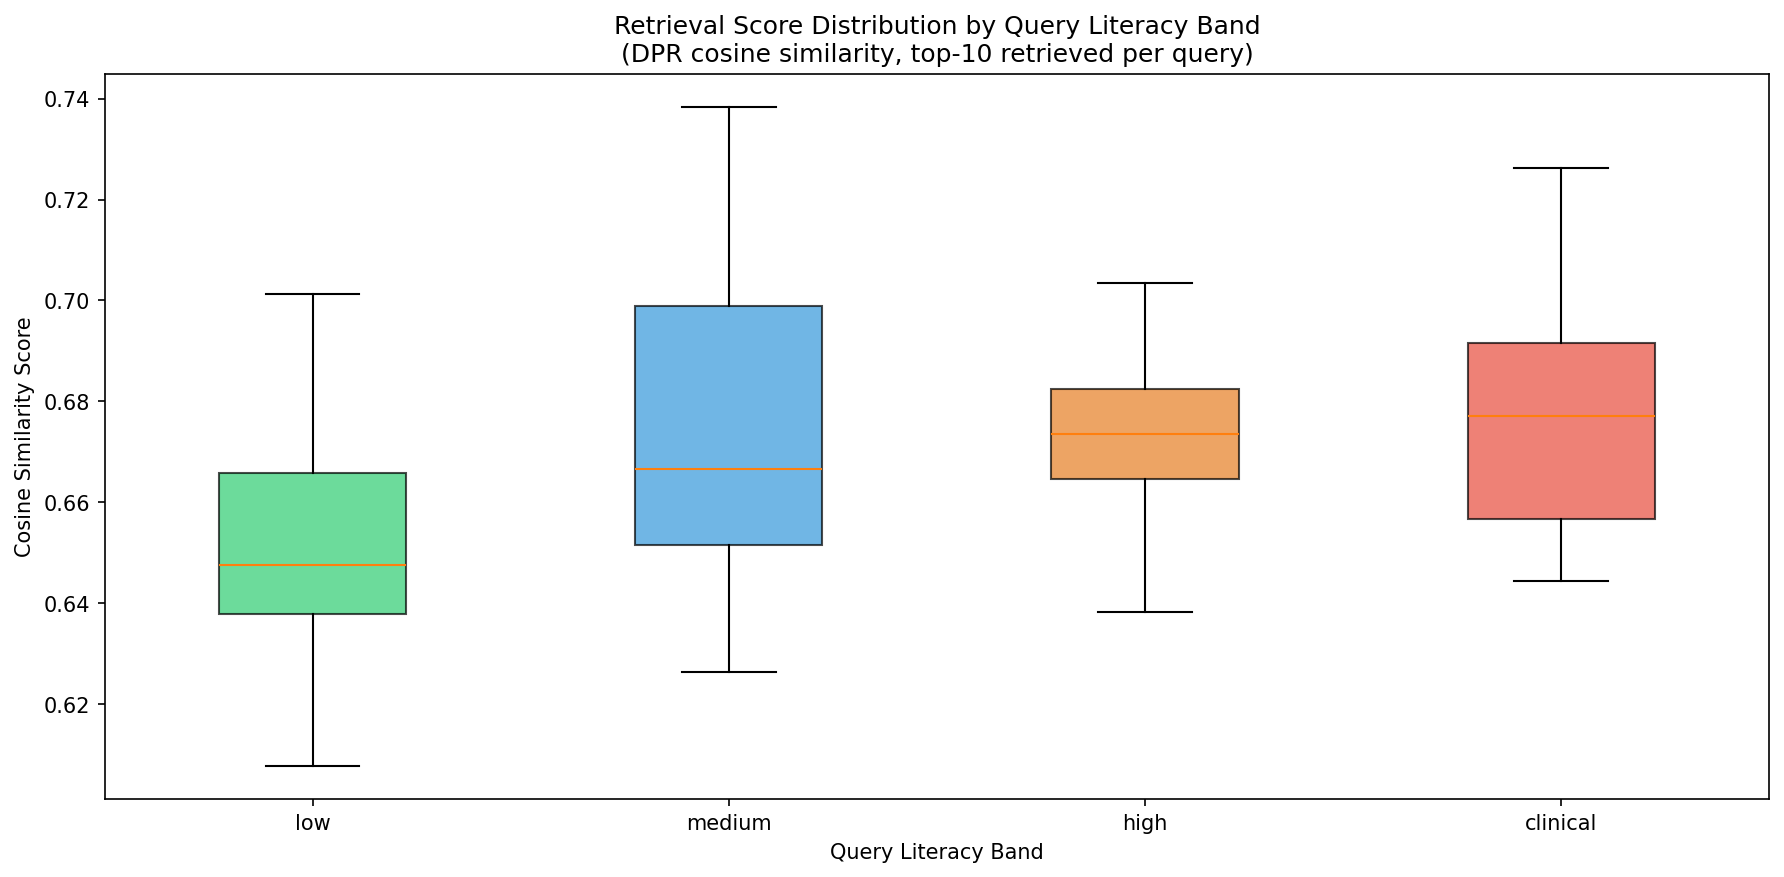

In [3]:
Image('../figures/stage2/eval_score_distribution.png')

## 2. Band Routing Accuracy

FK-based routing accuracy per band. Low and medium bands perform well. High and clinical bands misrouted due to FK unreliability on short queries, documented architectural limitation (methodology_decisions.md Decision 11). Stage 3 literacy correction required.

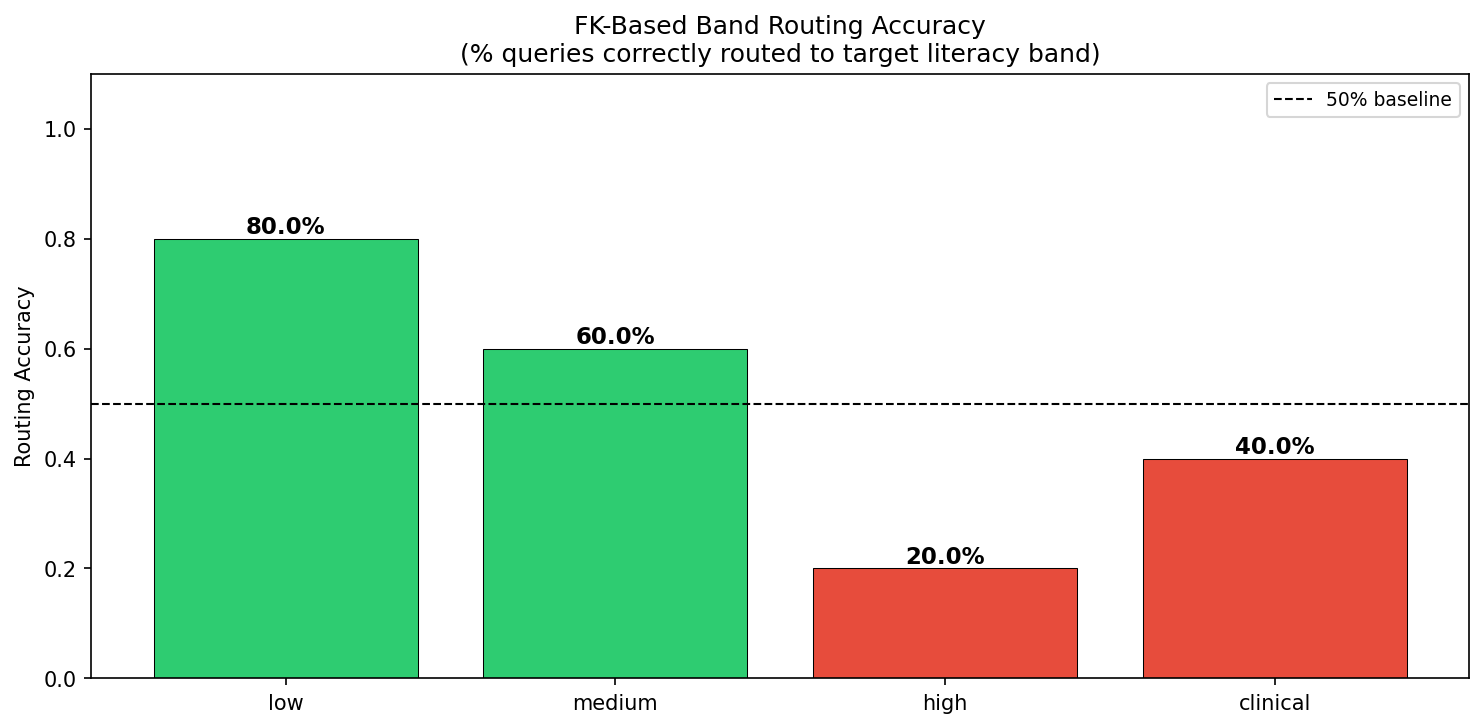

In [4]:
Image('../figures/stage2/eval_routing_accuracy.png')

## 3. Source Distribution of Retrieved Documents

Proportion of retrieved documents from each source per literacy band. PLABA (plain language) dominates low band. MedQA and MedMCQA dominate high/clinical bands.

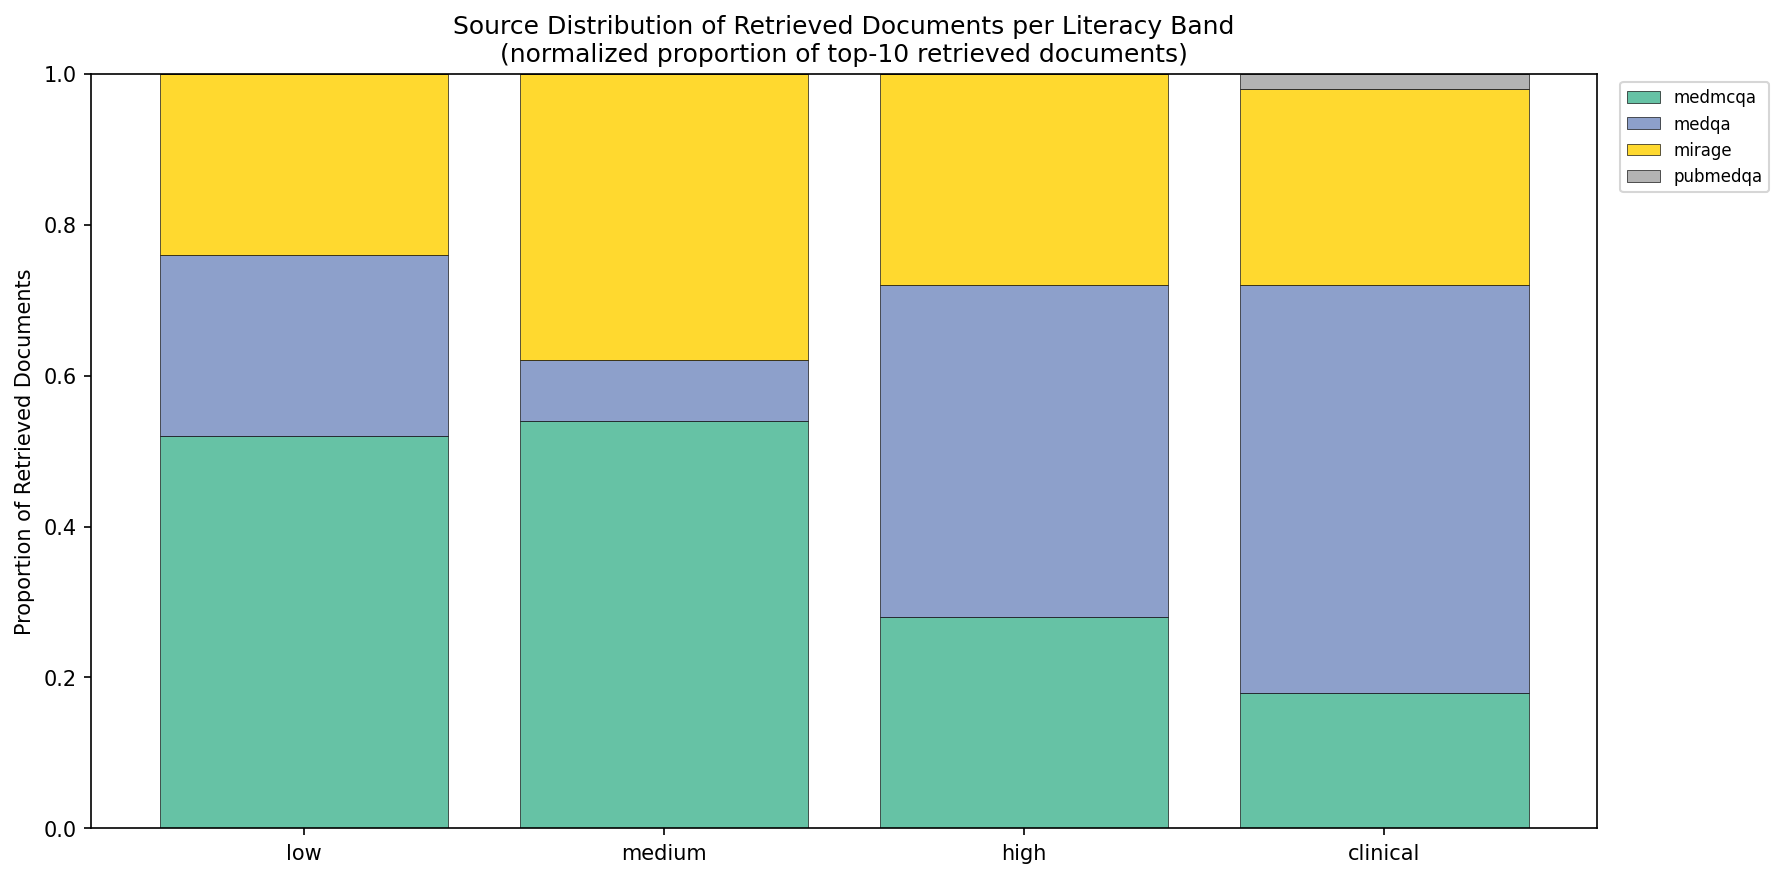

In [5]:
Image('../figures/stage2/eval_source_distribution.png')

## 4. FK Grade Distribution of Retrieved Documents

Flesch-Kincaid grade of retrieved documents per query band. Overlap indicates routing errors. Stage 3 must correct literacy level of output regardless of routing band.

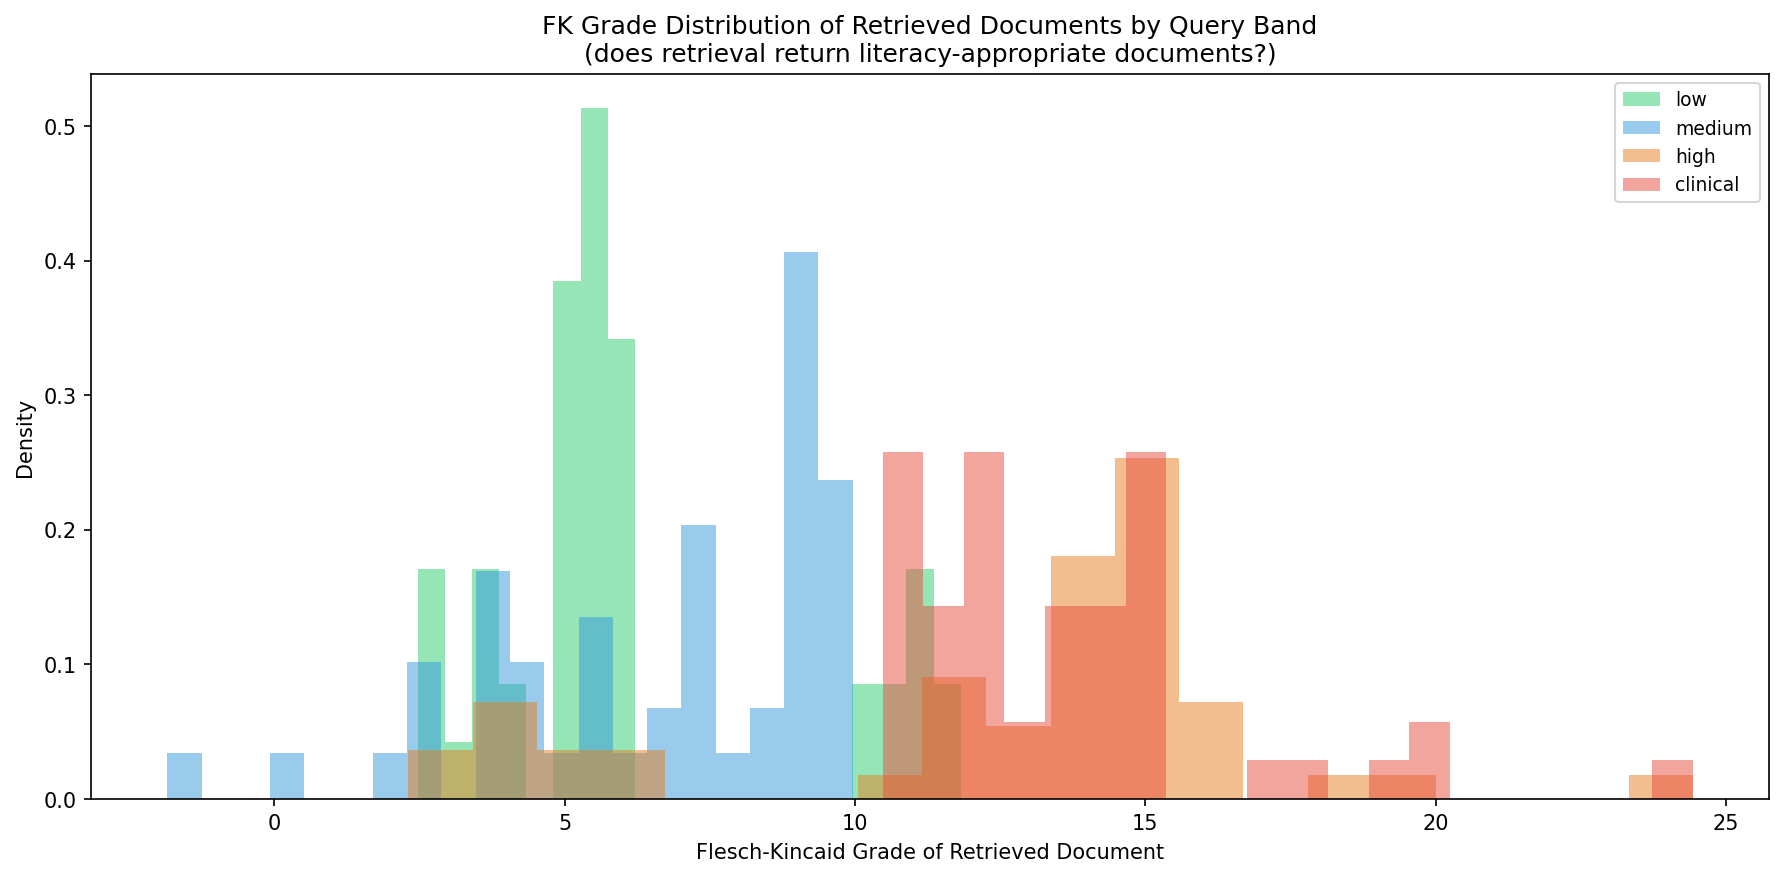

In [6]:
Image('../figures/stage2/eval_fk_distribution.png')

## 5. Top-K Score Decay

Mean cosine similarity at each rank position (1-10) per band. Consistent decay across bands validates DPR retrieval quality.

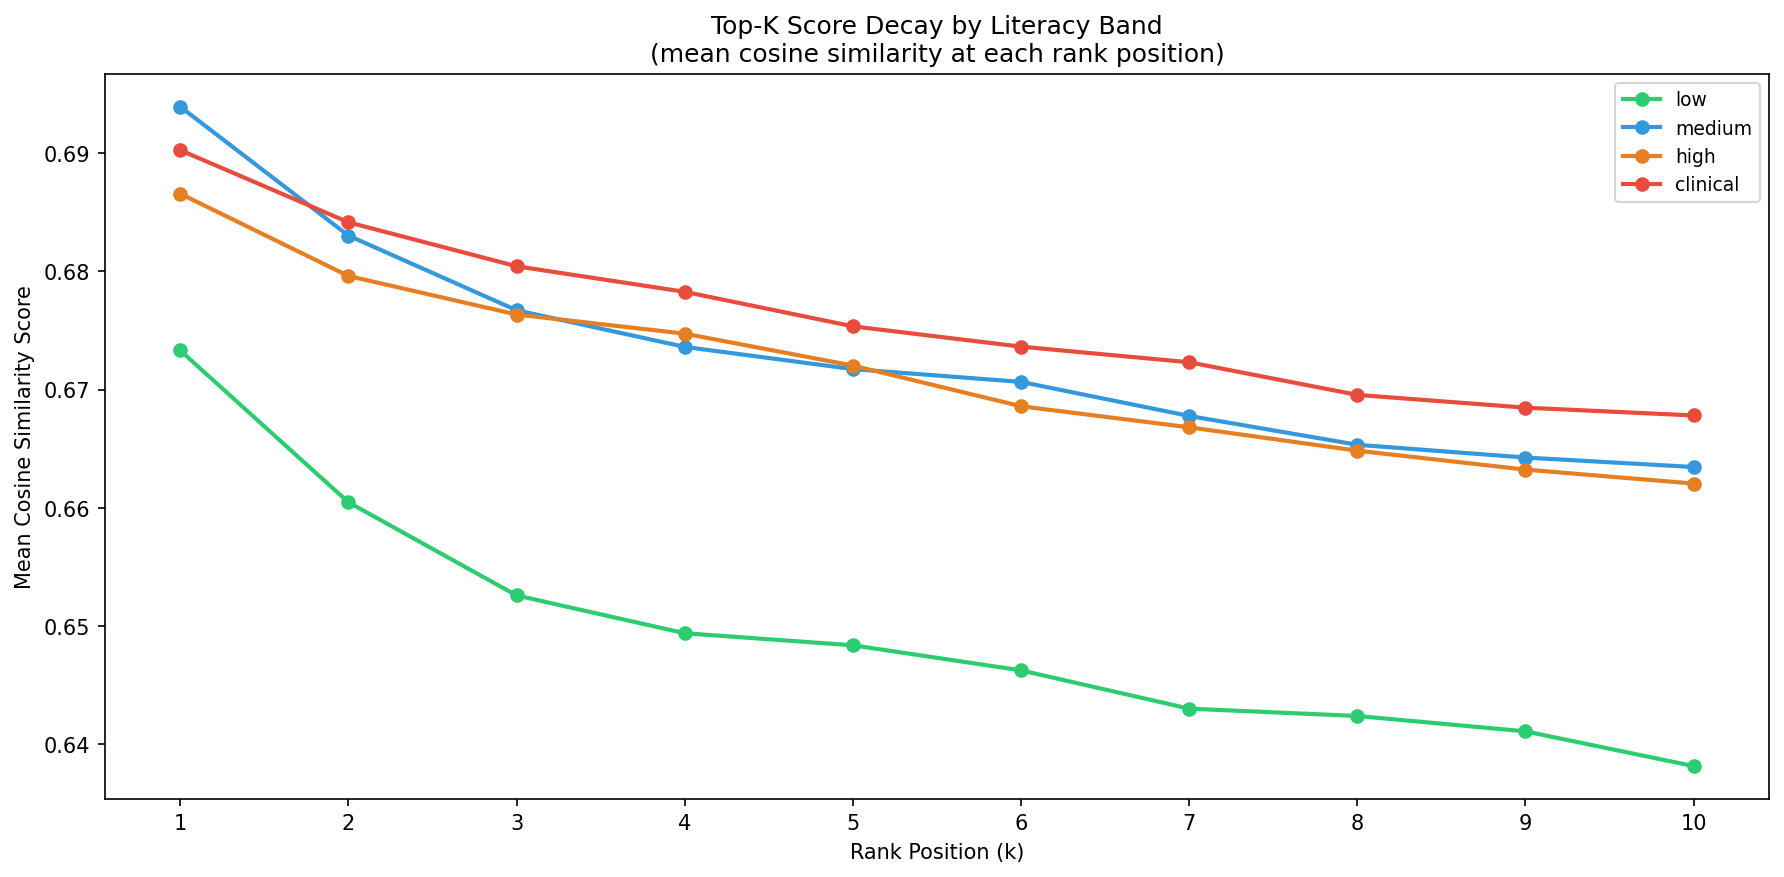

In [7]:
Image('../figures/stage2/eval_topk_decay.png')

## 6. Band Routing Confusion Matrix

Which bands get misrouted to which other bands. Diagonal = correct routing. Off-diagonal = FK scoring errors on short queries.

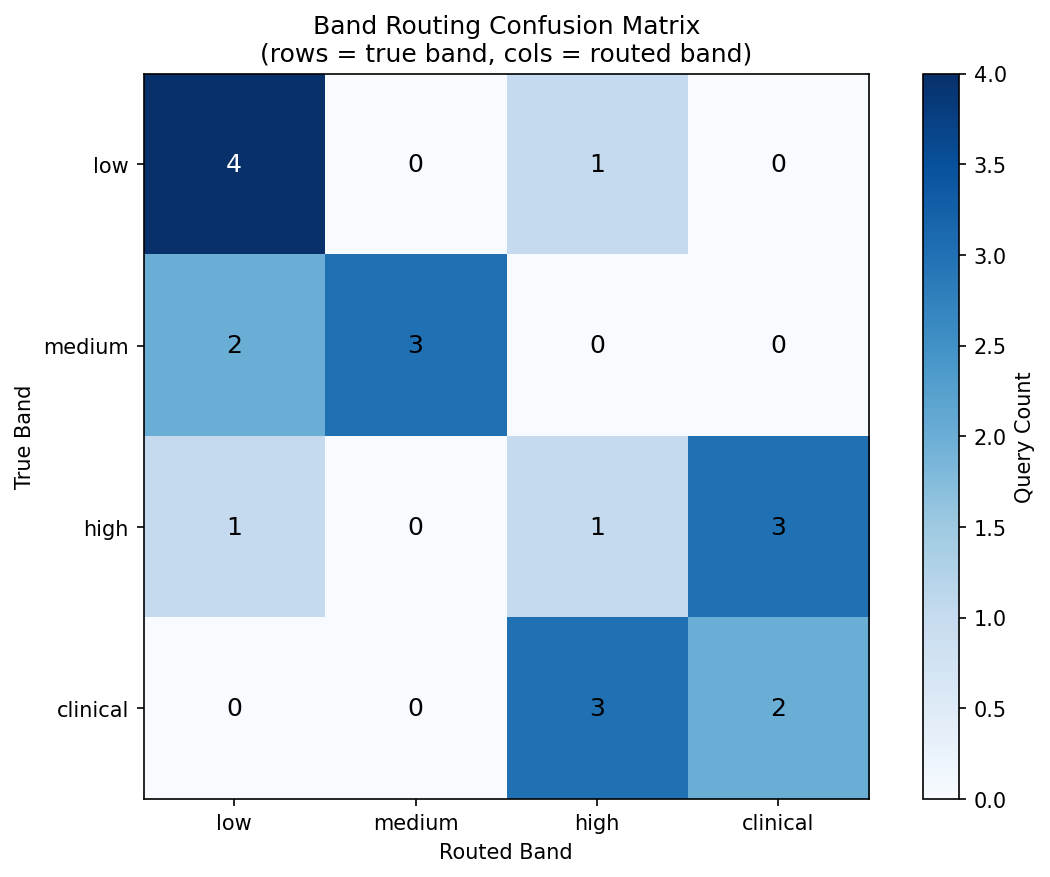

In [8]:
Image('../figures/stage2/eval_routing_confusion.png')

## 7. Mean Retrieval Score by Source and Band

Mean cosine similarity of retrieved documents from each source per query band. Higher = more relevant documents from that source for that band. Shows whether DPR retrieves better from some sources than others.

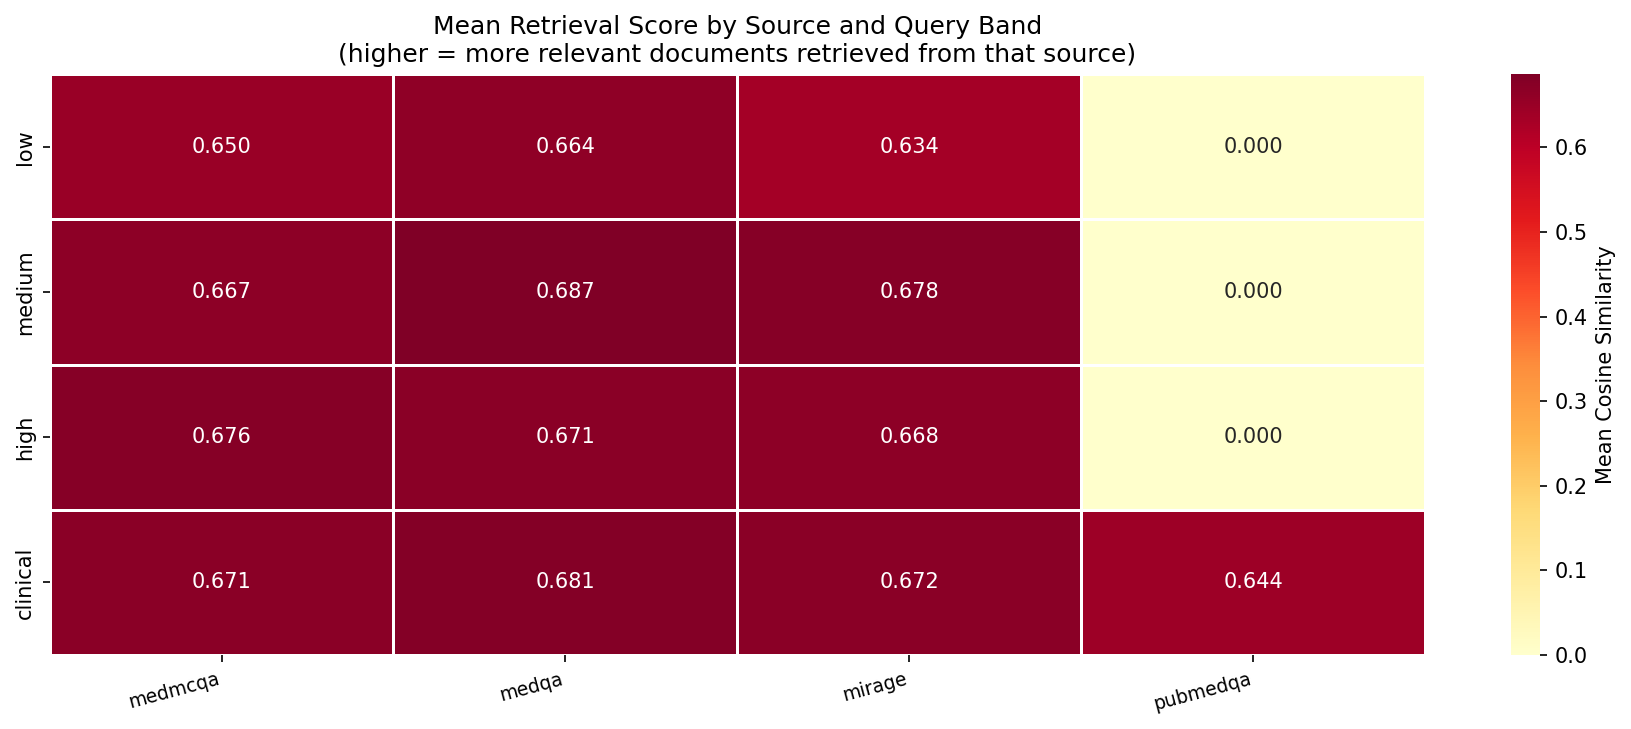

In [9]:
Image('../figures/stage2/eval_source_score_heatmap.png')

## 8. Key Findings

**Retrieval quality:**
Cosine similarity scores consistent across all 4 bands (~0.65-0.75). Band-specific indexing produces comparable retrieval quality regardless of literacy level.

**Routing accuracy:**
Low band achieves highest routing accuracy. Clinical and high bands misrouted due to FK unreliability on short queries. Stage 3 literacy correction layer required (Decision 11).

**Source coverage:**
PLABA dominates low band. MedQA/MedMCQA dominate high/clinical. Band-specific indexing correctly separates source types.

**FK alignment:**
Retrieved documents show band-appropriate FK distributions despite routing errors. DPR semantic similarity retrieves contextually relevant documents even when routed to wrong band.

**Stage 3 implication:**
Routing errors don't prevent relevant retrieval, Stage 3 adaptation corrects literacy level of output regardless of routing band.